In [3]:
# ── Cell 1: Dataset Overview ──────────────────────────────

print("="*60)
print("EDA — Dataset Overview")
print("="*60)

# Basic info
print(f"Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Null values : {df.isnull().sum().sum()}")

# Date range
if 'timestamp' in df.columns:
    print(f"Date range  : {df['timestamp'].min()} → {df['timestamp'].max()}")

# Column types
print("\nColumn types:")
print(df.dtypes.value_counts())

# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print("\nColumns with missing values:")
    print(missing)
else:
    print("\nNo missing values detected ✅")

# Statistical summary
print("\nStatistical summary (numeric features):")
display(df.describe().T)

# Categorical overview
print("\nCategorical overview:")
for col in df.select_dtypes(include='object').columns:
    print(f"  {col}: {df[col].nunique()} unique values")

# Insights
print("\nKey observations from statistics:")
print("- Features show varied ranges → scaling will be required")
print("- No missing values → dataset is clean and ready for modeling")
print("- Presence of multiple numerical features → suitable for ML models")
print("- Timestamp confirms multi-session data collection")

EDA — Dataset Overview
Shape       : 5,600 rows × 26 columns
Null values : 0
Date range  : 2026-01-28 13:18:12.843264 → 2026-02-12 16:37:42.789219

Column types:
float64           16
int64              7
object             2
datetime64[ns]     1
Name: count, dtype: int64

No missing values detected ✅

Statistical summary (numeric features):


,count,mean,min,25%,50%,75%,max,std
timestamp,5600,2026-01-29 23:04:50.513100288,2026-01-28 13:18:12.843264,2026-01-28 14:12:01.217112832,2026-01-28 14:56:26.309949952,2026-01-28 15:06:35.474565888,2026-02-12 16:37:42.789219,NaN
cpu_user_pct,5600.0,5.758866,0.0,0.77,2.785,8.0,97.87,7.845878
cpu_system_pct,5600.0,3.49023,0.0,0.26,0.73,1.9425,39.98,7.825055
cpu_idle_pct,5600.0,90.751054,-0.0,89.0925,96.53,98.92,100.0,15.12616
context_switch_rate,5600.0,1738.141493,44.0,260.0,399.0,748.0,24976.15,4086.317757
interrupt_rate,5600.0,2630.196325,26.0,498.0,800.0,1435.0,29995.29,5129.708906
load_avg_1m,5600.0,0.413821,0.02,0.22,0.32,0.47,2.57,0.334887
ram_used_mb,5600.0,1493.853098,1341.05,1444.66,1506.605,1518.0025,1719.95,67.231965
ram_free_mb,5600.0,2421.971745,2195.88,2397.8175,2409.215,2471.16,2574.78,67.23341
swap_used_mb,5600.0,0.026786,0.0,0.0,0.0,0.0,0.5,0.112595



Categorical overview:
  attack_type: 4 unique values
  system_phase: 3 unique values

Key observations from statistics:
- Features show varied ranges → scaling will be required
- No missing values → dataset is clean and ready for modeling
- Presence of multiple numerical features → suitable for ML models
- Timestamp confirms multi-session data collection


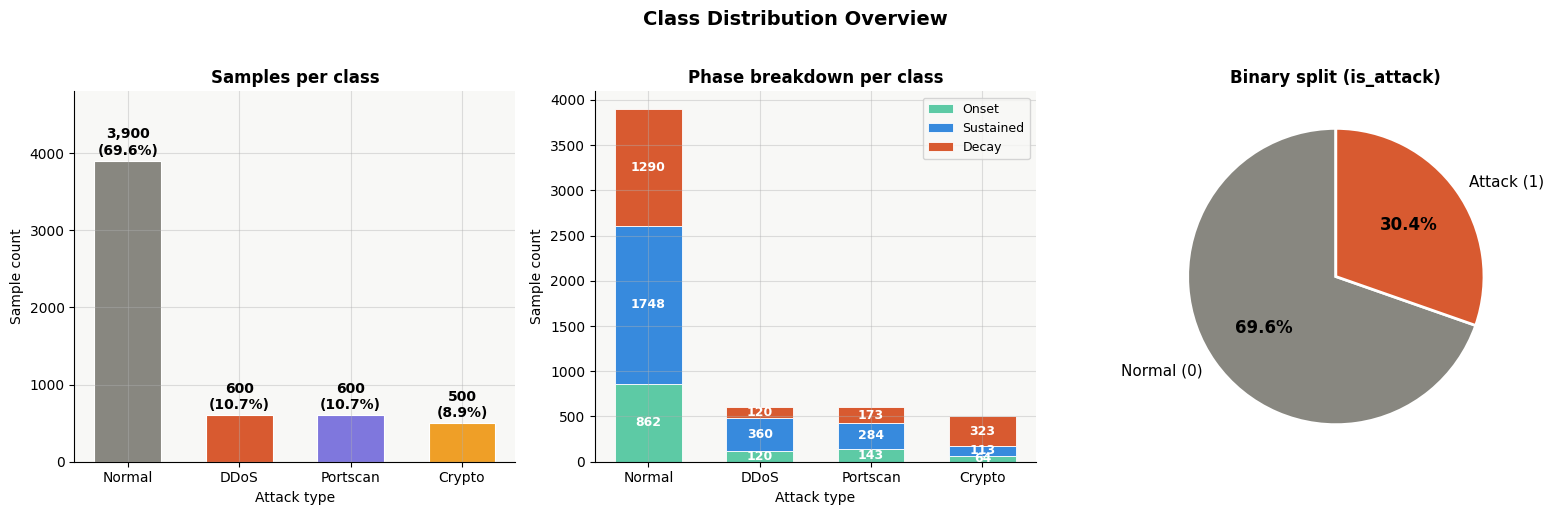

Key observations:
  Imbalance ratio  : 3900 normal vs 1700 attack (2.3:1)
  Smallest class   : crypto (500 samples, 8.9%)
  Implication      : accuracy is misleading — use F1 per class
  Action required  : SMOTE balancing before model training

Saved → ../outputs/figures\eda_01_class_distribution.png


In [ ]:
# ── Cell 2: Class Distribution ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Class Distribution Overview',
             fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: Sample count per class ───────────────────────
ax1 = axes[0]
# counts = df['attack_type'].value_counts().reindex(ATTACK_ORDER)
counts = df['attack_type'].value_counts().reindex(ATTACK_ORDER).fillna(0)
bars   = ax1.bar(
    [LABELS_MAP[k] for k in ATTACK_ORDER],
    counts.values,
    color=COLOR_LIST, edgecolor='white', linewidth=0.8, width=0.6
)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 40,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1.set_title('Samples per class', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sample count')
ax1.set_ylim(0, counts.max() * 1.2)
ax1.set_xlabel('Attack type')

# ── Plot 2: Phase breakdown stacked bar ──────────────────
ax2 = axes[1]
phase_colors = {
    'onset'    : '#5DCAA5',
    'sustained': '#378ADD',
    'decay'    : '#D85A30'
}
phase_data = (df.groupby(['attack_type','system_phase'])
                .size()
                .unstack(fill_value=0)
                .reindex(ATTACK_ORDER)[['onset','sustained','decay']])

bottom = np.zeros(4)
for phase in ['onset','sustained','decay']:
    vals = phase_data[phase].values
    bars = ax2.bar(
        [LABELS_MAP[k] for k in ATTACK_ORDER],
        vals, bottom=bottom,
        color=phase_colors[phase],
        edgecolor='white', linewidth=0.6,
        label=phase.capitalize(), width=0.6
    )
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 50:
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bot + val/2, str(val),
                     ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax2.set_title('Phase breakdown per class',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Sample count')
ax2.set_xlabel('Attack type')
ax2.legend(loc='upper right', fontsize=9)

# ── Plot 3: Binary pie ────────────────────────────────────
ax3 = axes[2]
binary = df['is_attack'].value_counts().sort_index()
wedges, texts, autotexts = ax3.pie(
    binary.values,
    labels=['Normal (0)', 'Attack (1)'],
    colors=[COLORS['none'], '#D85A30'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax3.set_title('Binary split (is_attack)',
              fontsize=12, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'eda_01_class_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Key observations ──────────────────────────────────────
print("Key observations:")
print(f"  Imbalance ratio  : {counts['none']} normal vs "
      f"{counts[['ddos','portscan','crypto']].sum()} attack "
      f"({counts['none']/counts[['ddos','portscan','crypto']].sum():.1f}:1)")
print(f"  Smallest class   : crypto ({counts['crypto']} samples, "
      f"{counts['crypto']/len(df)*100:.1f}%)")
print(f"  Implication      : accuracy is misleading — use F1 per class")
print(f"  Action required  : SMOTE balancing before model training")
print(f"\nSaved → {save_path}")

In [4]:
print(df.groupby(['attack_type','system_phase']).size())

attack_type  system_phase
crypto       decay            323
             onset             64
             sustained        113
ddos         decay            120
             onset            120
             sustained        360
none         decay           1290
             onset            862
             sustained       1748
portscan     decay            173
             onset            143
             sustained        284
dtype: int64


In [5]:
print("\nPhase Insights:\n")

print("- Normal traffic shows balanced phase distribution → realistic workload behavior")
print("- DDoS is dominated by sustained phase → continuous attack pressure")
print("- Portscan shows moderate spread across phases")
print("- Crypto shows skew toward decay → likely due to gradual CPU drop-off")
print("- system_phase can act as an informative feature for attack detection")


Phase Insights:

- Normal traffic shows balanced phase distribution → realistic workload behavior
- DDoS is dominated by sustained phase → continuous attack pressure
- Portscan shows moderate spread across phases
- Crypto shows skew toward decay → likely due to gradual CPU drop-off
- system_phase can act as an informative feature for attack detection



Using features:
['cpu_user_pct', 'cpu_system_pct', 'cpu_idle_pct', 'context_switch_rate', 'interrupt_rate', 'load_avg_1m', 'ram_used_mb', 'ram_free_mb', 'swap_used_mb', 'total_process_count', 'total_thread_count', 'high_cpu_process_count', 'top_process_cpu_pct', 'top_process_uptime_sec', 'packets_recv_per_sec', 'packets_sent_per_sec', 'tcp_connection_count', 'failed_connection_attempts', 'unique_dst_port_count', 'is_legitimate_peak', 'pi_ram_used_mb', 'pi_ram_free_mb']

Generating distribution plots...



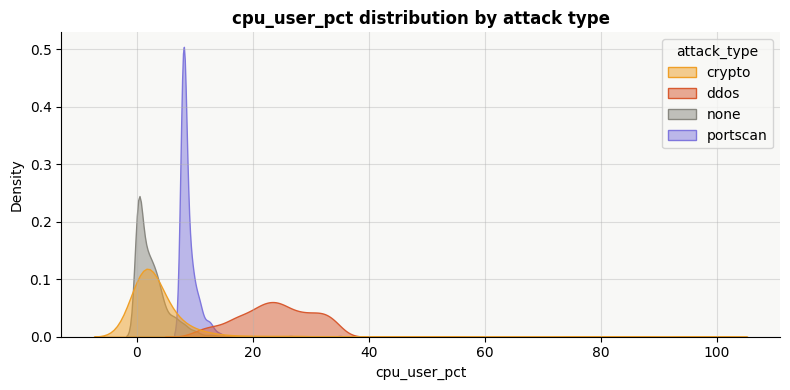

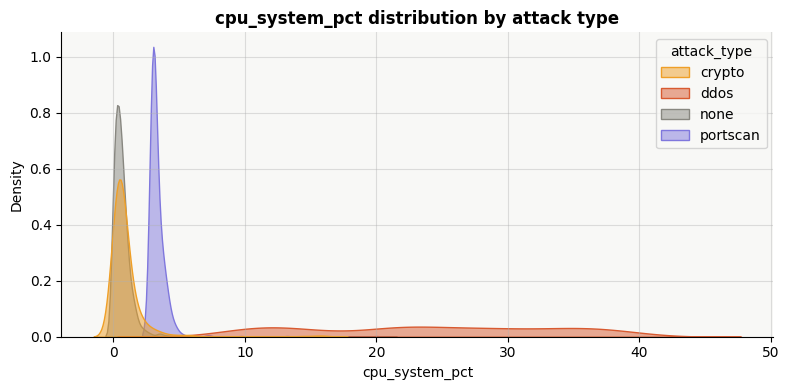

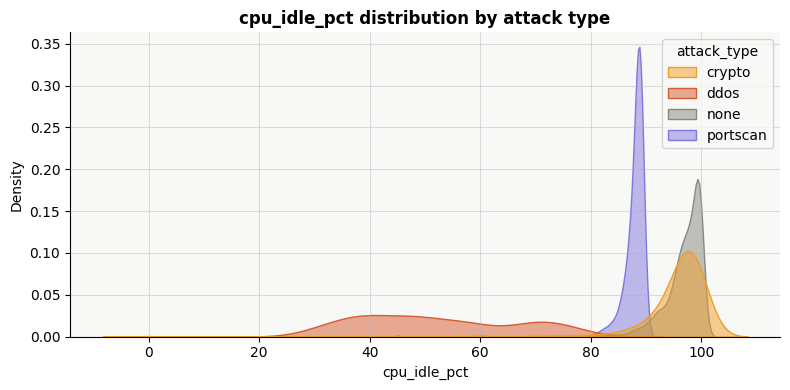

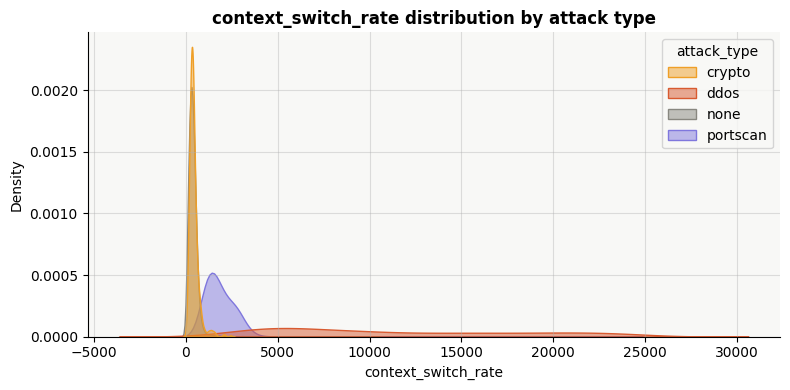

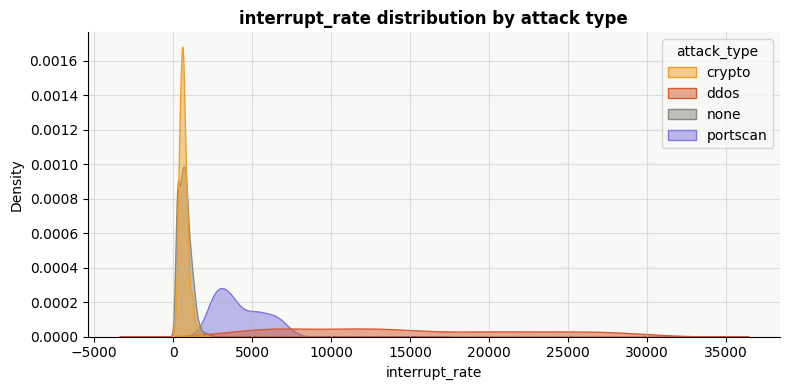

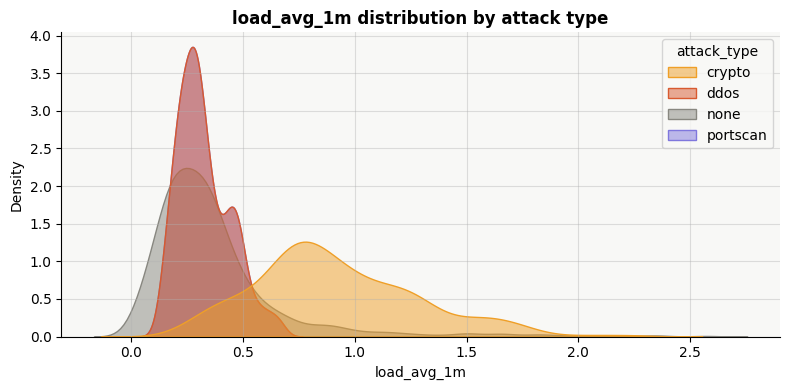

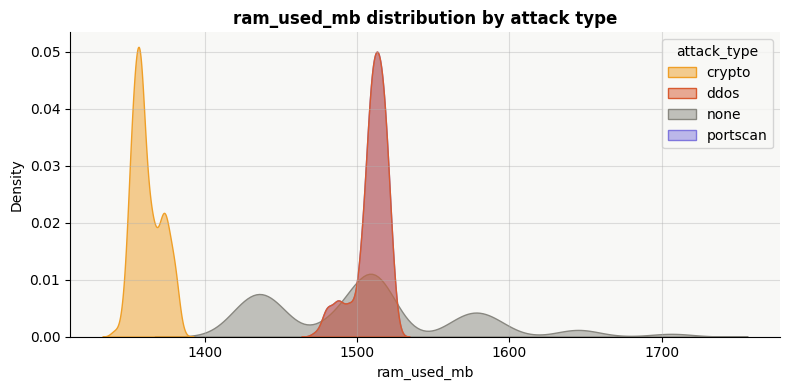

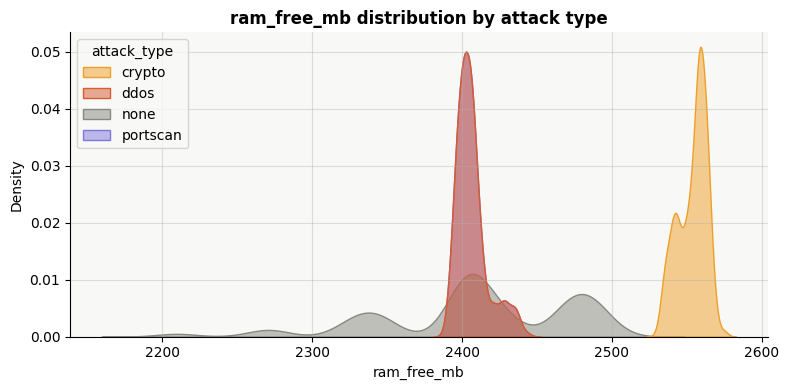

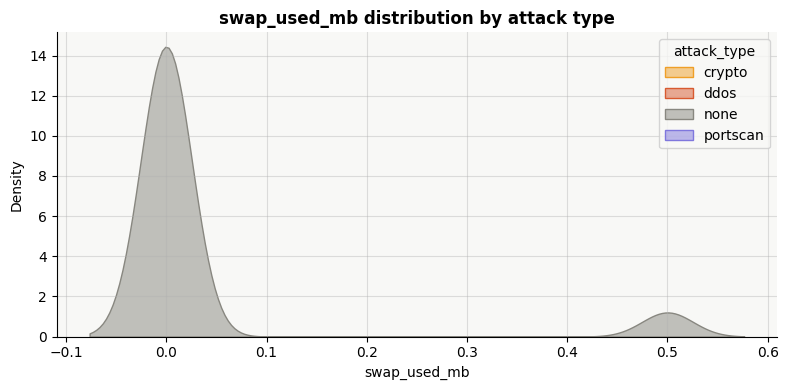

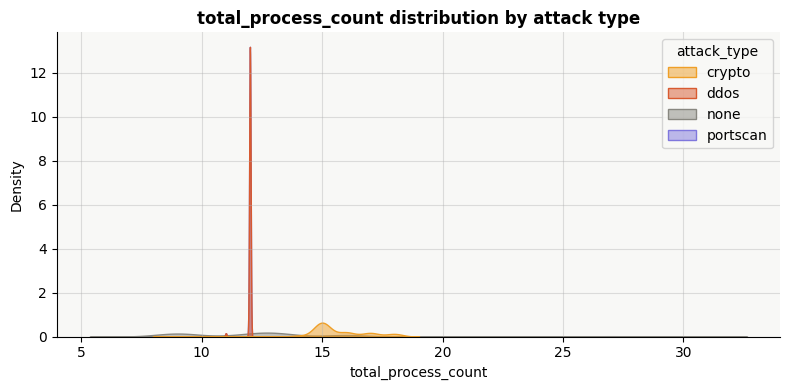

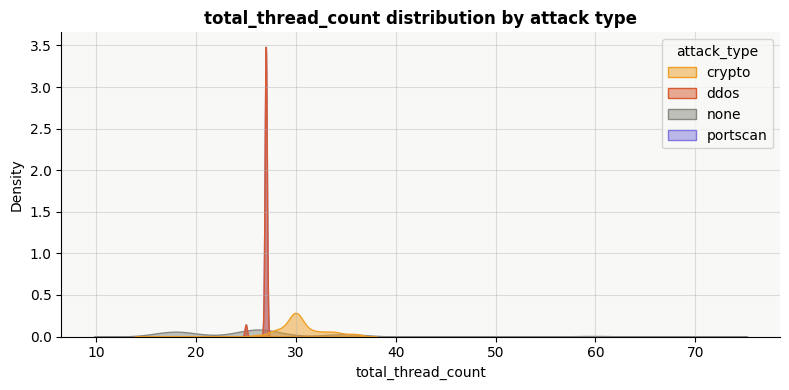

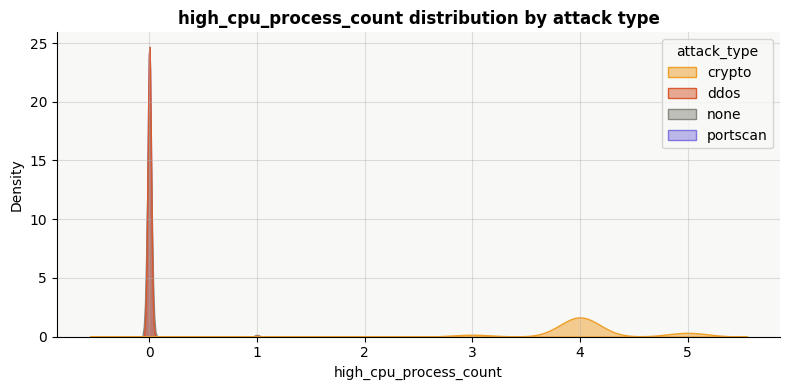

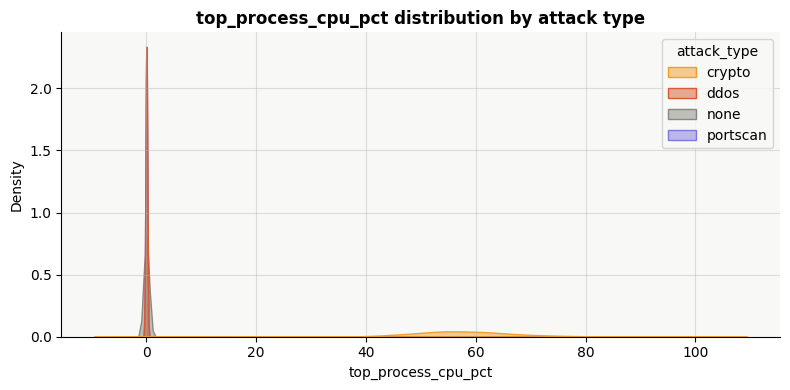

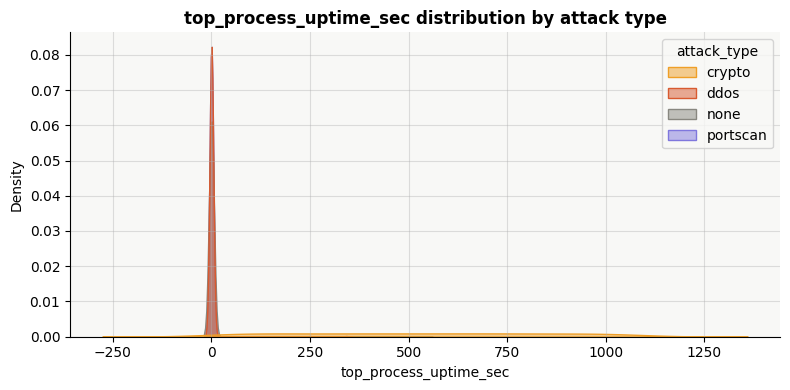

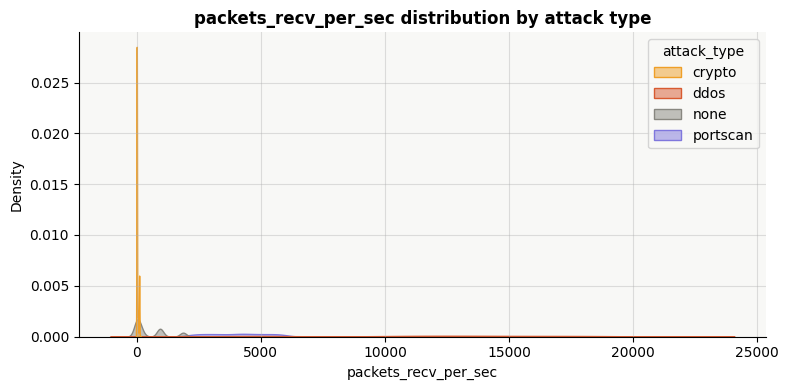

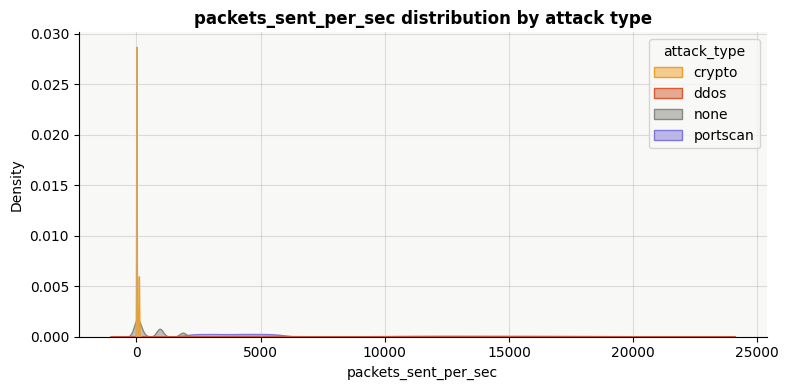

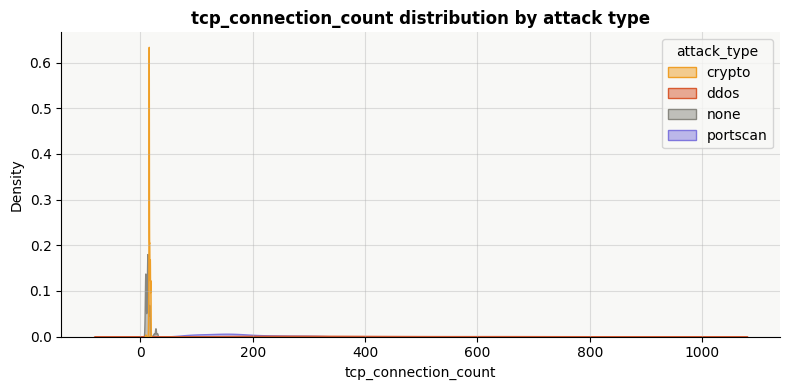

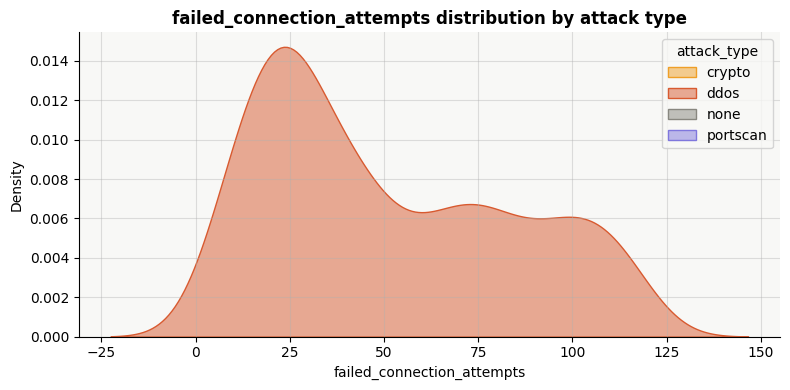

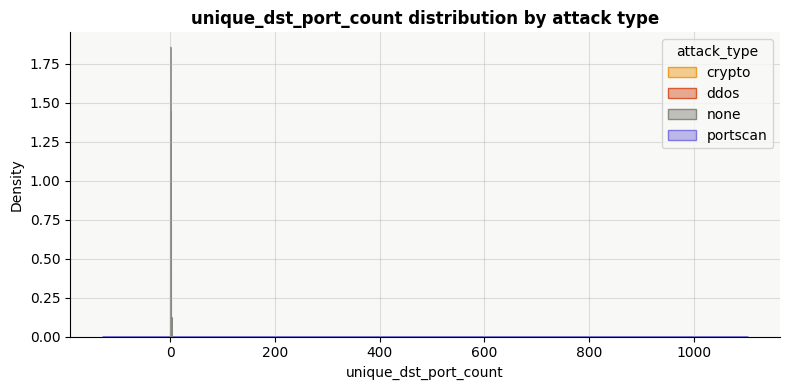

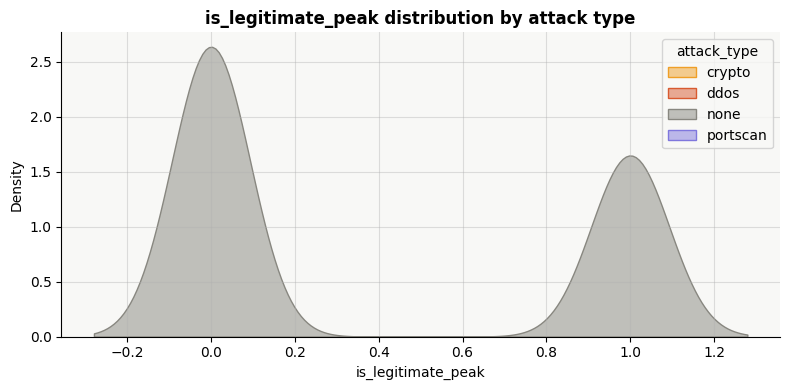

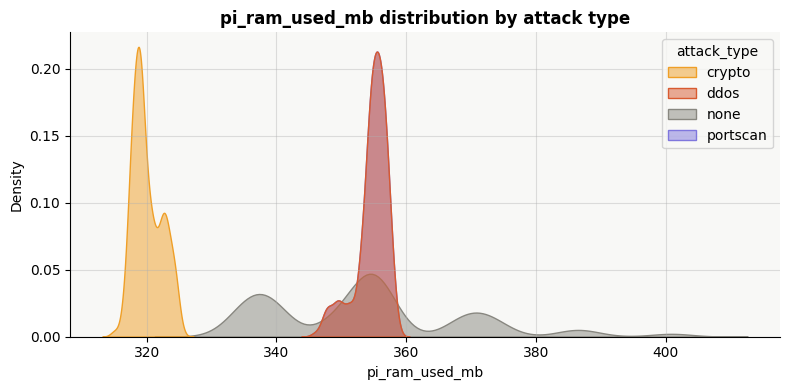

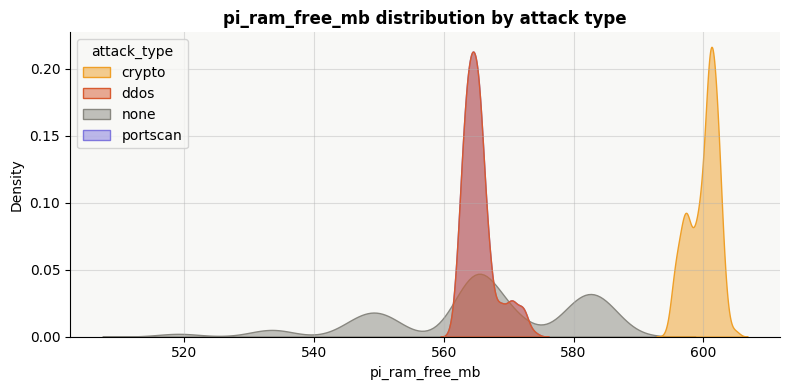


Generating boxplots...



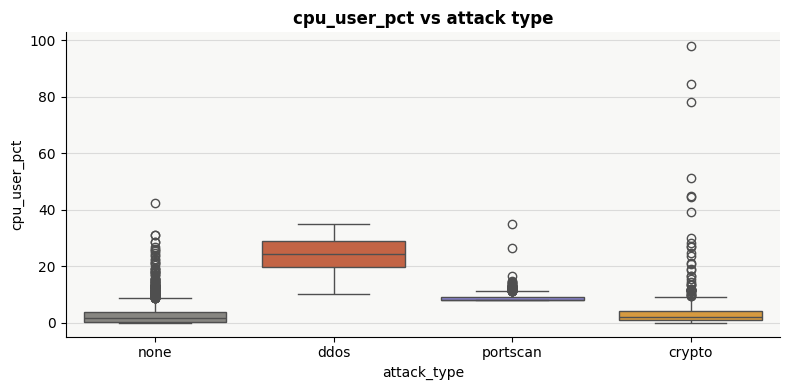

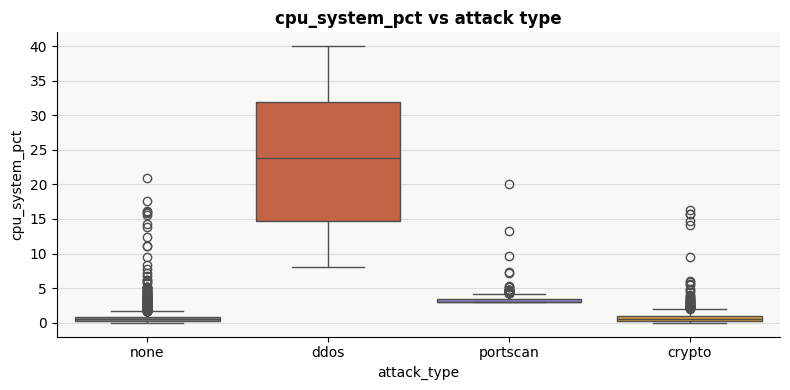

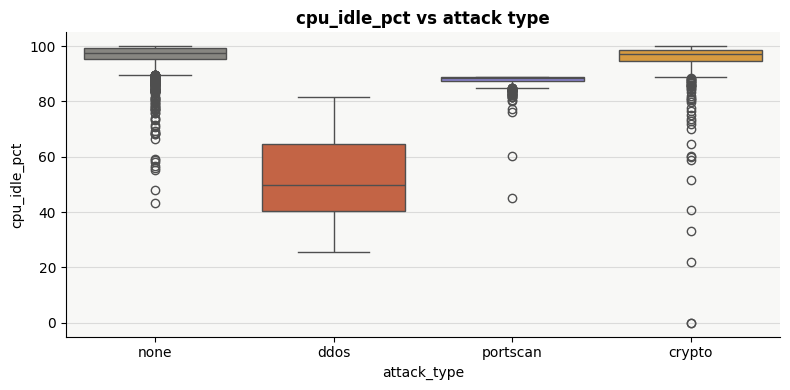

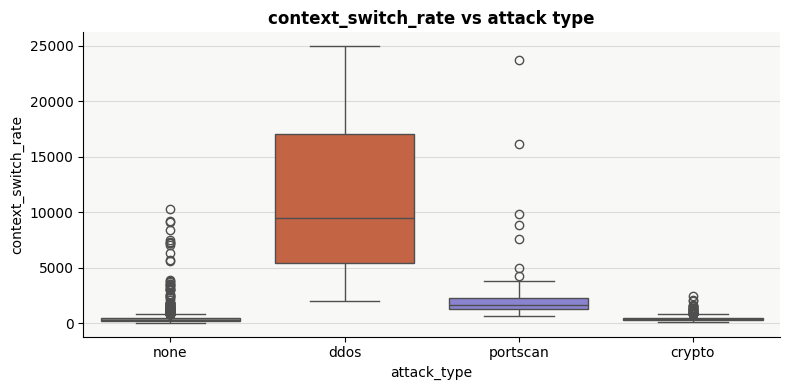

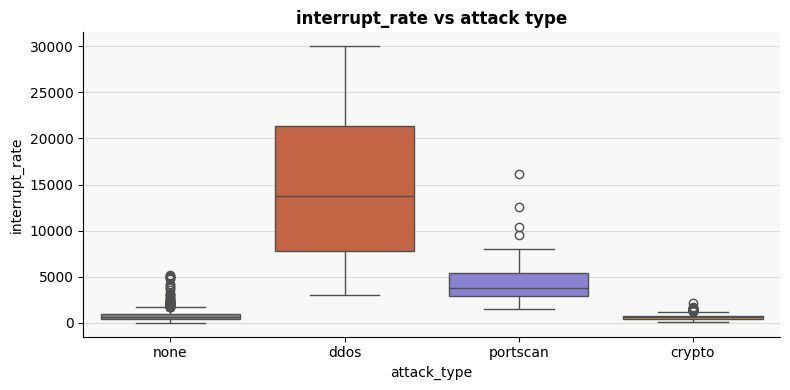

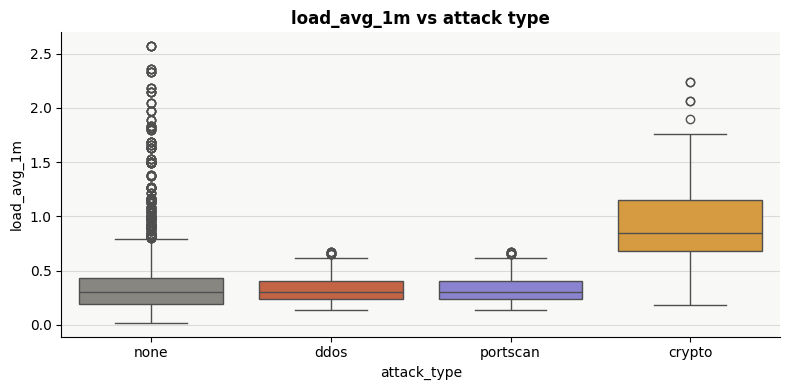

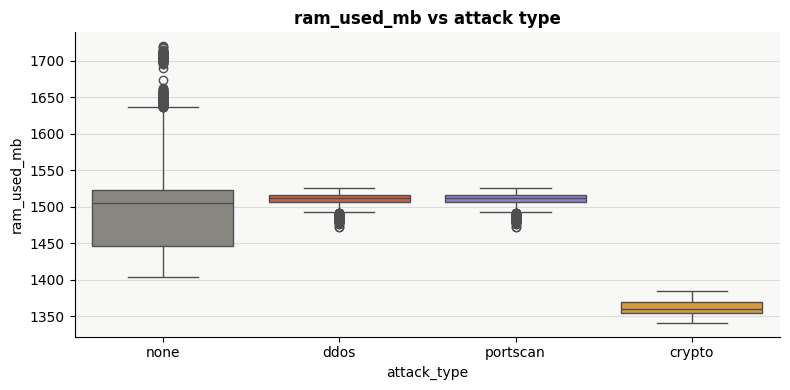

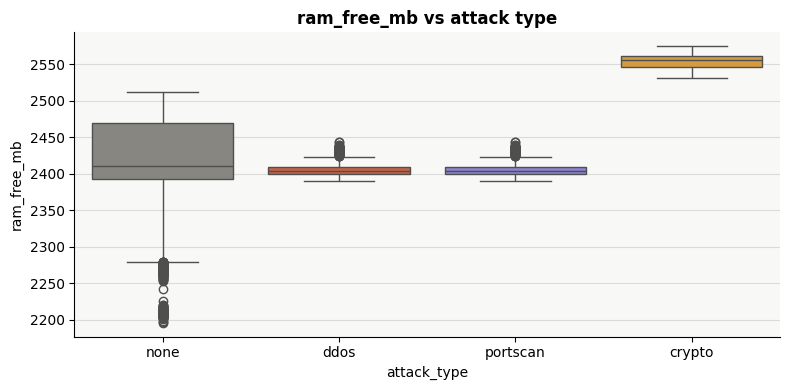

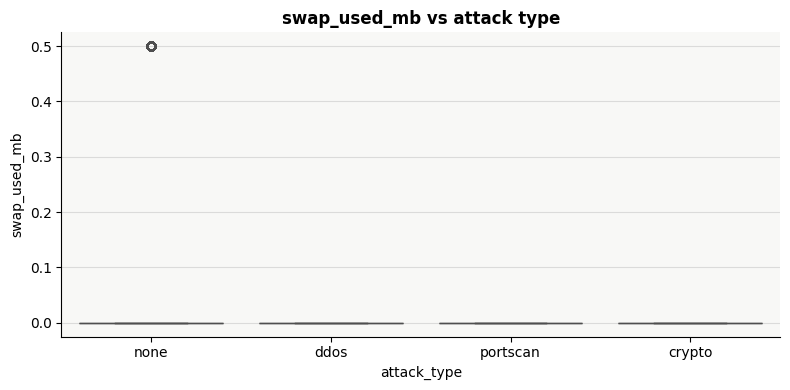

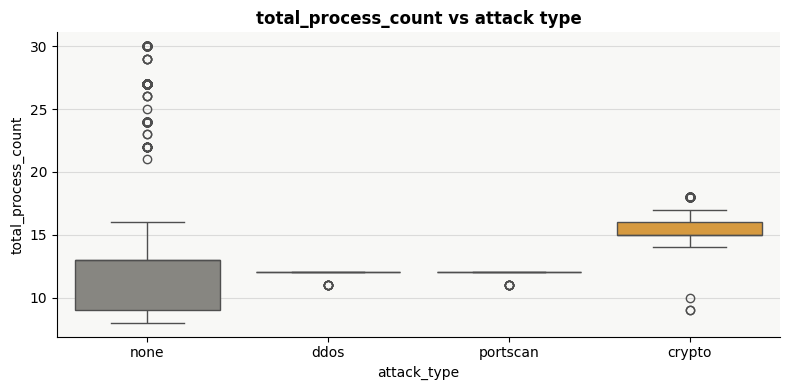

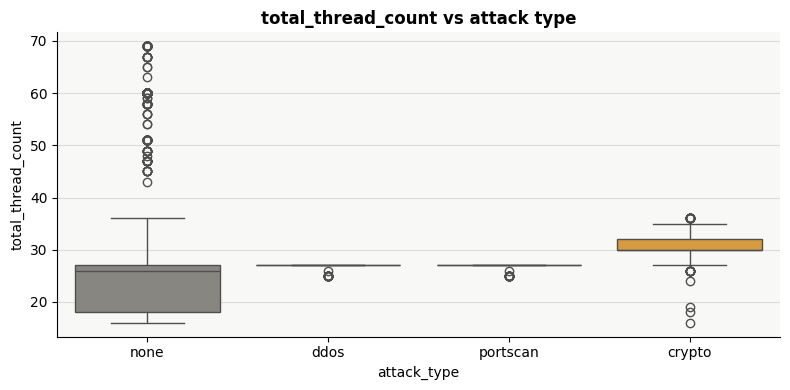

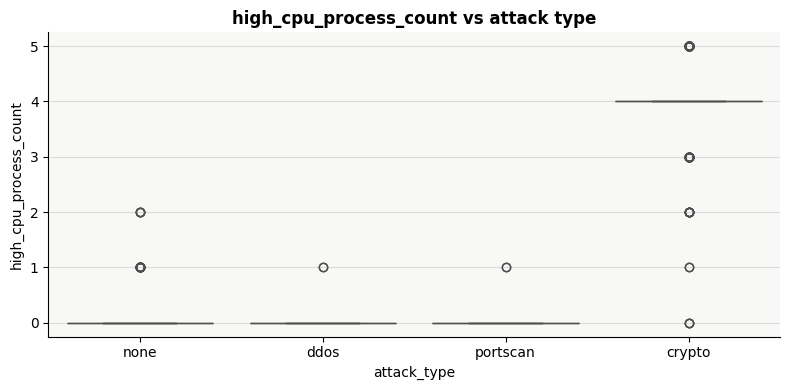

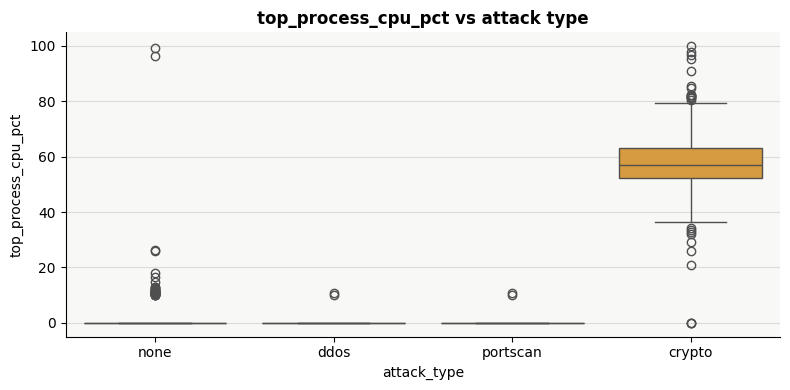

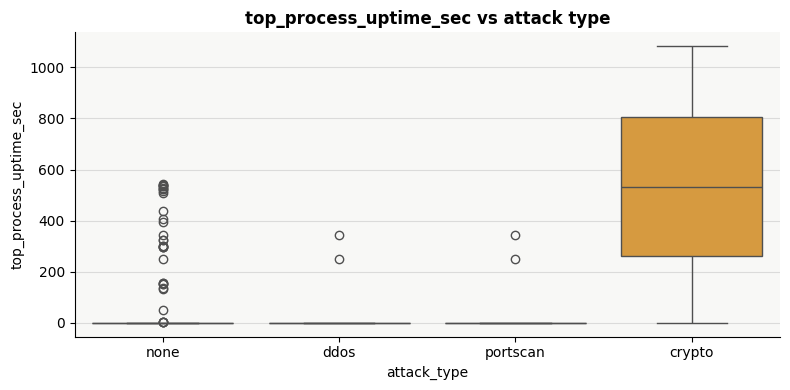

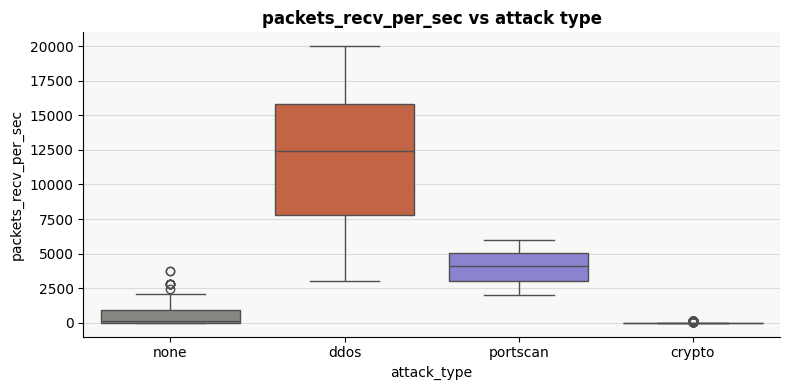

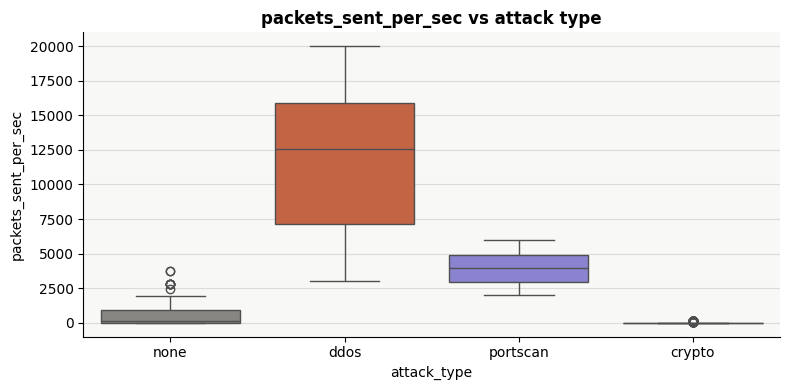

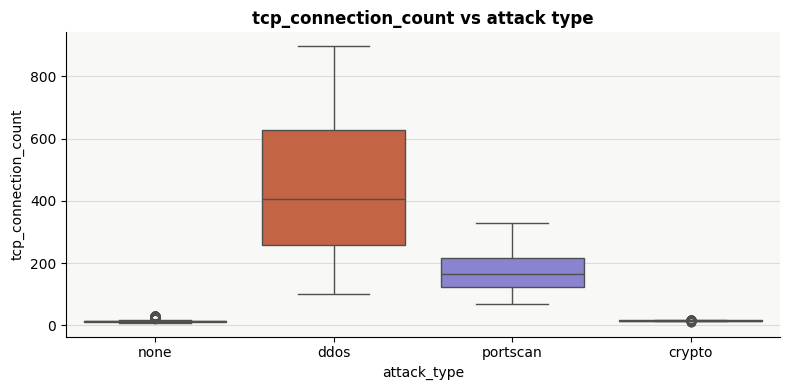

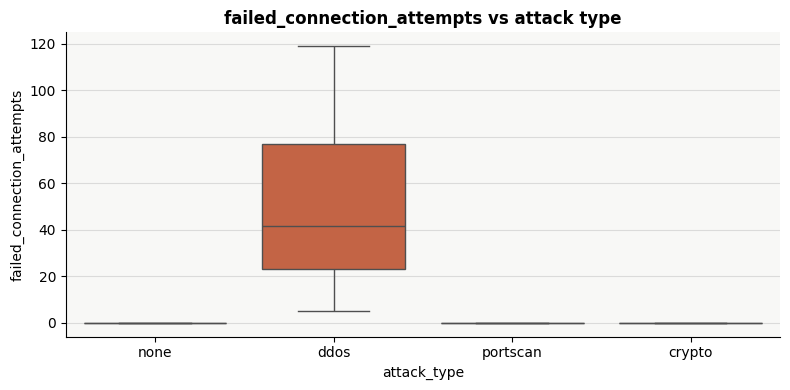

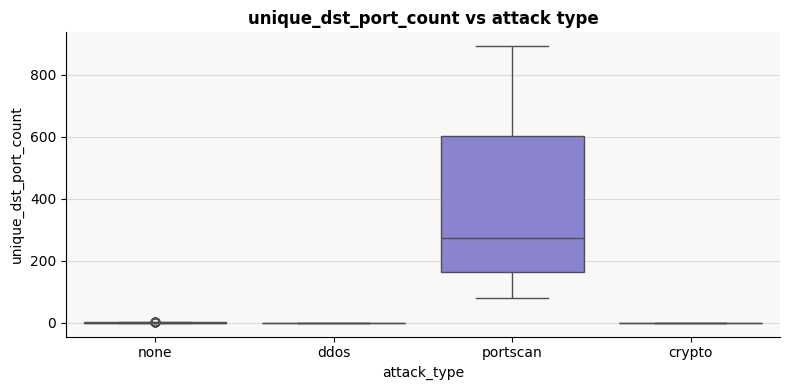

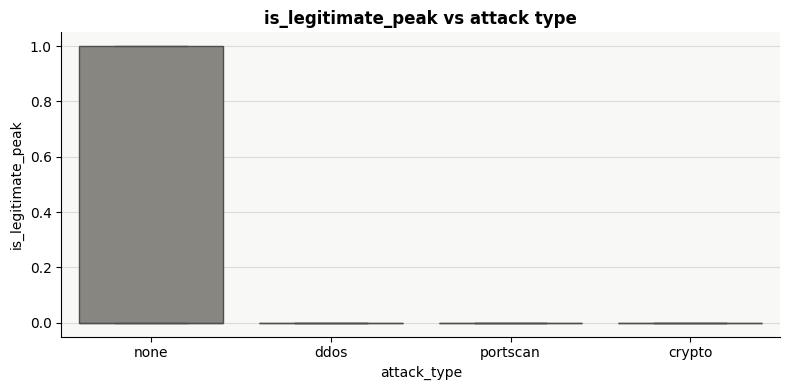

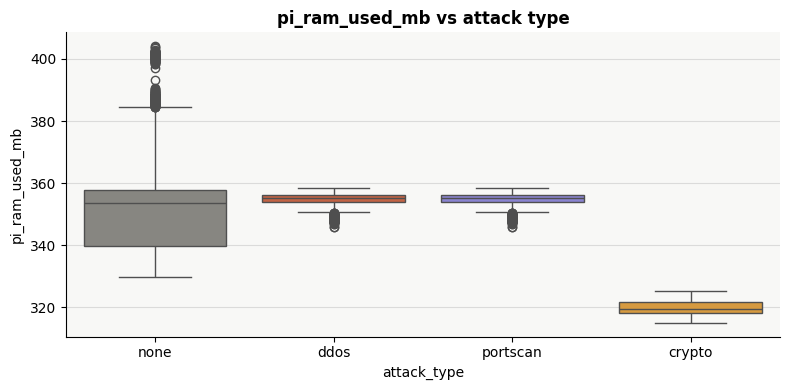

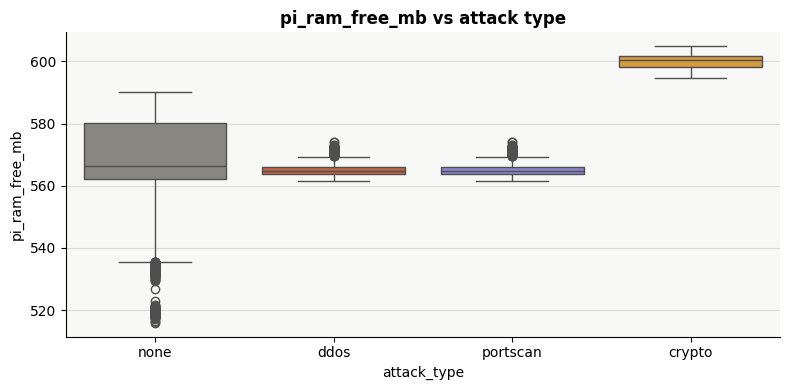


Feature Means (Table 1):



,cpu_user_pct,cpu_system_pct,cpu_idle_pct,context_switch_rate,interrupt_rate,load_avg_1m,ram_used_mb,ram_free_mb,swap_used_mb,total_process_count,...,top_process_cpu_pct,top_process_uptime_sec,packets_recv_per_sec,packets_sent_per_sec,tcp_connection_count,failed_connection_attempts,unique_dst_port_count,is_legitimate_peak,pi_ram_used_mb,pi_ram_free_mb
attack_type,,,,,,,,,,,,,,,,,,,,,
crypto,4.202080,0.969280,94.828700,420.038000,664.040000,0.917560,1362.111860,2553.720000,0.000000,15.692000,...,57.773000,534.784000,19.410000,19.236000,15.692000,0.00000,0.000000,0.000000,320.019240,599.980760
ddos,23.955067,23.942533,52.102400,11397.251600,14990.874533,0.325067,1509.547817,2406.276033,0.000000,11.988333,...,0.034833,0.986667,11873.916950,11949.212533,448.692617,50.81965,0.000000,0.000000,354.659600,565.340400
none,2.677233,0.689521,96.633454,394.544872,732.079744,0.376549,1505.913856,2409.910392,0.038462,13.114103,...,0.150564,2.615385,512.451538,512.288718,13.114103,0.00000,0.511538,0.384615,353.805687,566.194313
portscan,8.890600,3.343333,87.766067,1910.829000,4245.739500,0.325067,1509.547817,2406.276033,0.000000,11.988333,...,0.034833,0.986667,4049.269567,3951.721083,174.435500,0.00000,375.860000,0.000000,354.659600,565.340400



ANOVA Results (Feature Importance):

cpu_user_pct              p-value = 0.000000 → SIGNIFICANT ✅
cpu_system_pct            p-value = 0.000000 → SIGNIFICANT ✅
cpu_idle_pct              p-value = 0.000000 → SIGNIFICANT ✅
context_switch_rate       p-value = 0.000000 → SIGNIFICANT ✅
interrupt_rate            p-value = 0.000000 → SIGNIFICANT ✅
load_avg_1m               p-value = 0.000000 → SIGNIFICANT ✅
ram_used_mb               p-value = 0.000000 → SIGNIFICANT ✅
ram_free_mb               p-value = 0.000000 → SIGNIFICANT ✅
swap_used_mb              p-value = 0.000000 → SIGNIFICANT ✅
total_process_count       p-value = 0.000000 → SIGNIFICANT ✅
total_thread_count        p-value = 0.000000 → SIGNIFICANT ✅
high_cpu_process_count    p-value = 0.000000 → SIGNIFICANT ✅
top_process_cpu_pct       p-value = 0.000000 → SIGNIFICANT ✅
top_process_uptime_sec    p-value = 0.000000 → SIGNIFICANT ✅
packets_recv_per_sec      p-value = 0.000000 → SIGNIFICANT ✅
packets_sent_per_sec      p-value = 0.000000 → 

In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║           Cell 3 — Feature-wise Analysis (Final)        ║
# ╚══════════════════════════════════════════════════════════╝

# ── Step 1: Identify usable numeric features ──────────────
exclude_cols = ['is_attack']  # add more if needed

features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in exclude_cols
]

print("\nUsing features:")
print(features)

# ── Sanity check ──────────────────────────────────────────
if len(features) == 0:
    raise ValueError("❌ No numeric features found. Check dataset columns.")

# ── Step 2: Distribution plots ────────────────────────────
print("\nGenerating distribution plots...\n")

for col in features:
    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df,
        x=col,
        hue='attack_type',
        fill=True,
        common_norm=False,
        alpha=0.5,
        palette=COLORS
    )

    plt.title(f"{col} distribution by attack type",
              fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/eda_dist_{col}.png", dpi=300)
    plt.show()


# ── Step 3: Boxplots ──────────────────────────────────────
print("\nGenerating boxplots...\n")

for col in features:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x='attack_type',
        y=col,
        order=ATTACK_ORDER,
        palette=COLOR_LIST
    )

    plt.title(f"{col} vs attack type",
              fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/eda_box_{col}.png", dpi=300)
    plt.show()


# ── Step 4: Feature Means (Table 1) ───────────────────────
print("\nFeature Means (Table 1):\n")

feature_means = df.groupby('attack_type')[features].mean()
display(feature_means)

feature_means.to_csv(f"{FIGURES_DIR}/table1_feature_means.csv")


# ── Step 5: Statistical Significance ──────────────────────
from scipy.stats import f_oneway

print("\nANOVA Results (Feature Importance):\n")

significant_features = []

for col in features:
    groups = [df[df['attack_type']==atk][col] for atk in ATTACK_ORDER]
    
    # Avoid empty groups
    if any(len(g) == 0 for g in groups):
        print(f"{col:<25} skipped (missing class data)")
        continue

    stat, p = f_oneway(*groups)

    if p < 0.05:
        significant_features.append(col)
        status = "SIGNIFICANT ✅"
    else:
        status = "NOT significant ❌"

    print(f"{col:<25} p-value = {p:.6f} → {status}")


# ── Step 6: Final Insights ────────────────────────────────
print("\nKey Insights:\n")

print(f"- Total features analyzed     : {len(features)}")
print(f"- Significant features       : {len(significant_features)}")

if len(significant_features) > 0:
    print("- Strong candidates for ML   :", significant_features[:5])

print("\nInterpretation:")
print("- Features with clear separation → good for classification")
print("- Features with extreme values → useful for anomaly detection")
print("- Overlapping distributions → weaker predictors")

print("\nSaved plots →", FIGURES_DIR)

selected_features = [
    'failed_connection_attempts',
    'packets_sent_per_sec',
    'packets_recv_per_sec',
    'tcp_connection_count',
    'context_switch_rate',
    'unique_dst_port_count',
    'top_process_cpu_pct',
    'cpu_user_pct',
    'load_avg_1m'
]

### Feature Selection Summary

To ensure effective detection of cyber-attacks in IoT environments, feature selection was performed based on exploratory data analysis (EDA), focusing on distribution separability, statistical significance, and domain relevance.

A subset of high-impact features was selected that exhibited clear behavioral differences across attack types, enabling both anomaly detection and classification tasks.

#### Selected Features

The final feature set includes:

* **Network Activity Features**

  * `packets_sent_per_sec`
  * `packets_recv_per_sec`
  * `tcp_connection_count`
  * `failed_connection_attempts`
  * `unique_dst_port_count`

* **System Performance Features**

  * `cpu_user_pct`
  * `context_switch_rate`
  * `load_avg_1m`

* **Process-Level Features**

  * `top_process_cpu_pct`

#### Feature Relevance by Attack Type

* **DDoS Attacks**
  Characterized by extreme spikes in network traffic and connection attempts.
  Key indicators: `packets_sent_per_sec`, `packets_recv_per_sec`, `tcp_connection_count`, `failed_connection_attempts`, `context_switch_rate`.

* **Port Scanning Attacks**
  Identified by a high diversity of destination ports accessed.
  Key indicator: `unique_dst_port_count`.

* **Cryptojacking (Crypto Mining)**
  Exhibits elevated CPU utilization at the process level with relatively low network activity.
  Key indicators: `top_process_cpu_pct`, `cpu_user_pct`, `load_avg_1m`.

* **Normal Activity**
  Displays stable and low-variance behavior across all selected features.

#### Justification

Features were selected based on:

* Clear separation in distribution plots (KDE and boxplots)
* Statistical significance (ANOVA tests)
* Domain-specific relevance to known attack behaviors

Redundant and low-impact features (e.g., memory metrics and swap usage) were excluded to reduce noise and improve model efficiency.

#### Outcome

The selected feature set provides:

* High discriminative power for classification models
* Strong deviation signals for anomaly detection
* Improved interpretability and reduced model complexity

This forms the foundation for subsequent feature engineering and model development in the CyberSentinel system.


In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Cell 3.5 — Create Feature-Selected Dataset         ║
# ╚══════════════════════════════════════════════════════════╝

# Final selected features
selected_features = [
    'failed_connection_attempts',
    'packets_sent_per_sec',
    'packets_recv_per_sec',
    'tcp_connection_count',
    'context_switch_rate',
    'unique_dst_port_count',
    'top_process_cpu_pct',
    'cpu_user_pct',
    'load_avg_1m'
]

# Target columns
target_cols = ['attack_type', 'is_attack']

# Safety check
missing = [f for f in selected_features if f not in df.columns]
if missing:
    print("⚠️ Missing features:", missing)

# Create new dataset
df_selected = df[selected_features + target_cols].copy()

print("\nNew dataset shape:", df_selected.shape)
display(df_selected.head())

# Save
save_path = "../data/processed/feature_selected.csv"
df_selected.to_csv(save_path, index=False)

print(f"\nSaved → {save_path}")


New dataset shape: (5600, 11)


,failed_connection_attempts,packets_sent_per_sec,packets_recv_per_sec,tcp_connection_count,context_switch_rate,unique_dst_port_count,top_process_cpu_pct,cpu_user_pct,load_avg_1m,attack_type,is_attack
0,0.0,0.0,0.0,9.0,567.0,0,0.0,6.21,0.18,crypto,1
1,0.0,0.0,0.0,9.0,803.0,0,0.0,1.50,0.41,crypto,1
2,0.0,0.0,0.0,10.0,893.0,0,0.0,5.68,0.41,crypto,1
3,0.0,0.0,0.0,14.0,404.0,0,26.0,4.99,0.41,crypto,1
4,0.0,0.0,0.0,14.0,496.0,0,59.9,2.17,0.37,crypto,1



Saved → ../data/processed/feature_selected.csv
